# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Импорты, seed и устройство

In [5]:
import os
import random
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
print(f'PyTorch версия: {torch.__version__}')
print(f'Torchvision версия: {torchvision.__version__}')

Устройство: cpu
PyTorch версия: 2.10.0+cpu
Torchvision версия: 0.25.0+cpu


## 2. Данные и DataLoader

Используем датасет **EMNIST Balanced**. 

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

print(f"Количество классов: {len(train_full.classes)}")
print(f"Размер тренировочной выборки (полной): {len(train_full)}")
print(f"Размер тестовой выборки: {len(test_ds)}")

val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

print(f"Размер тренировочной выборки (реальной): {len(train_ds)}")
print(f"Размер валидационной выборки: {len(val_ds)}")

BATCH_SIZE = 128
NUM_WORKERS = 0 if os.name == 'nt' else 2

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda')
)

x_batch, y_batch = next(iter(train_loader))
print(f"Форма батча x: {x_batch.shape}, dtype: {x_batch.dtype}")
print(f"Форма батча y: {y_batch.shape}, dtype: {y_batch.dtype}")
print(f"Мин. значение x: {x_batch.min():.3f}, макс. значение x: {x_batch.max():.3f}")

100.0%


Количество классов: 47
Размер тренировочной выборки (полной): 112800
Размер тестовой выборки: 18800
Размер тренировочной выборки (реальной): 90240
Размер валидационной выборки: 22560
Форма батча x: torch.Size([128, 1, 28, 28]), dtype: torch.float32
Форма батча y: torch.Size([128]), dtype: torch.int64
Мин. значение x: -1.000, макс. значение x: 1.000


## 3. Модель MLP и вспомогательные функции

In [8]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """Вычисляет accuracy для батча логов."""
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def plot_history(history: dict, title: str = ""):
    """Рисует графики loss и accuracy."""
    epochs = np.arange(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title(f'{title} (Loss)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.title(f'{title} (Accuracy)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Модель MLP
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,  # EMNIST Balanced имеет 47 классов
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Функции для обучения и валидации
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

# EarlyStopping
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# Основной цикл обучения
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if verbose:
            print(f"epoch {epoch:02d}/{epochs} | train loss={tr_loss:.4f}, acc={tr_acc:.4f} | val loss={va_loss:.4f}, acc={va_acc:.4f}")

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(f"EarlyStopping: остановка на эпохе {epoch}. Лучший val_acc={early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break
    return history

## 4. Часть A (S08): регуляризация


### E1 (base)

MLP (256, 128), без Dropout и BatchNorm.

In [9]:
torch.manual_seed(SEED)
model_e1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False, num_classes=47).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_e1 = fit(model_e1, train_loader, val_loader, optimizer_e1, criterion, device, epochs=15, verbose=False)
best_val_acc_e1 = max(history_e1['val_acc'])
print(f"Лучшая val_accuracy для E1: {best_val_acc_e1:.4f}")

Лучшая val_accuracy для E1: 0.8388


### E2 (Dropout)

In [11]:
torch.manual_seed(SEED)
model_e2 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)

history_e2 = fit(model_e2, train_loader, val_loader, optimizer_e2, criterion, device, epochs=15, verbose=False)
best_val_acc_e2 = max(history_e2['val_acc'])
print(f"Лучшая val_accuracy для E2: {best_val_acc_e2:.4f}")

Лучшая val_accuracy для E2: 0.8258


### E3 (BatchNorm)

In [13]:
torch.manual_seed(SEED)
model_e3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True, num_classes=47).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)

history_e3 = fit(model_e3, train_loader, val_loader, optimizer_e3, criterion, device, epochs=15, verbose=False)
best_val_acc_e3 = max(history_e3['val_acc'])
print(f"Лучшая val_accuracy для E3: {best_val_acc_e3:.4f}")

Лучшая val_accuracy для E3: 0.8491


### E4 (EarlyStopping)

In [15]:
torch.manual_seed(SEED)
model_e4 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)

es = EarlyStopping(patience=3, min_delta=0.001)
history_e4 = fit(model_e4, train_loader, val_loader, optimizer_e4, criterion, device, epochs=30, early_stopping=es, verbose=False)

best_val_acc_e4 = es.best_score
print(f"Лучшая val_accuracy для E4: {best_val_acc_e4:.4f}")

Лучшая val_accuracy для E4: 0.8315


Лучшая модель сохранена в artifacts\best_model.pt
Конфиг сохранён в artifacts\best_config.json


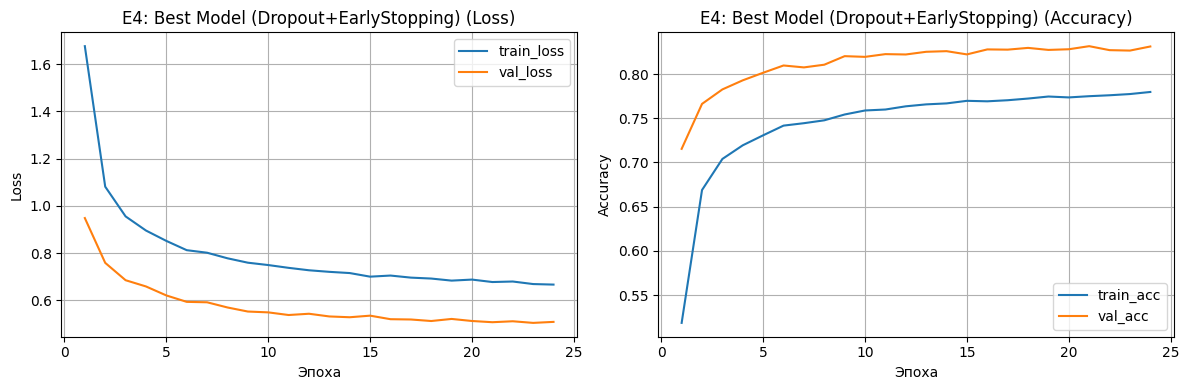

График лучшей модели сохранён в artifacts\figures\curves_best.png


<Figure size 640x480 with 0 Axes>

In [16]:
# Сохраняем лучшую модель
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)
torch.save(es.best_state, artifacts_dir / 'best_model.pt')
print(f"Лучшая модель сохранена в {artifacts_dir / 'best_model.pt'}")

# Сохраняем конфиг лучшей модели
best_config = {
    'dataset': 'EMNIST',
    'seed': SEED,
    'model': 'MLP',
    'hidden_dims': [256, 128],
    'dropout_p': 0.3,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'best_val_accuracy': best_val_acc_e4
}
with open(artifacts_dir / 'best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)
print(f"Конфиг сохранён в {artifacts_dir / 'best_config.json'}")

# График для лучшей модели
figures_dir = artifacts_dir / 'figures'
figures_dir.mkdir(exist_ok=True)
plot_history(history_e4, title="E4: Best Model (Dropout+EarlyStopping)")
plt.savefig(figures_dir / 'curves_best.png')
print(f"График лучшей модели сохранён в {figures_dir / 'curves_best.png'}")

## 5. Часть B (S09): LR, оптимизаторы, weight decay

### O1 (LR слишком большой)

In [18]:
torch.manual_seed(SEED)
model_o1 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8, verbose=False)

### O2 (LR слишком маленький)

In [19]:
torch.manual_seed(SEED)
model_o2 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8, verbose=False)

### O3 (SGD+momentum + weight decay)

In [20]:
torch.manual_seed(SEED)
model_o3 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False, num_classes=47).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, device, epochs=12, verbose=False)


### График для "плохих" LR (O1 и O2)

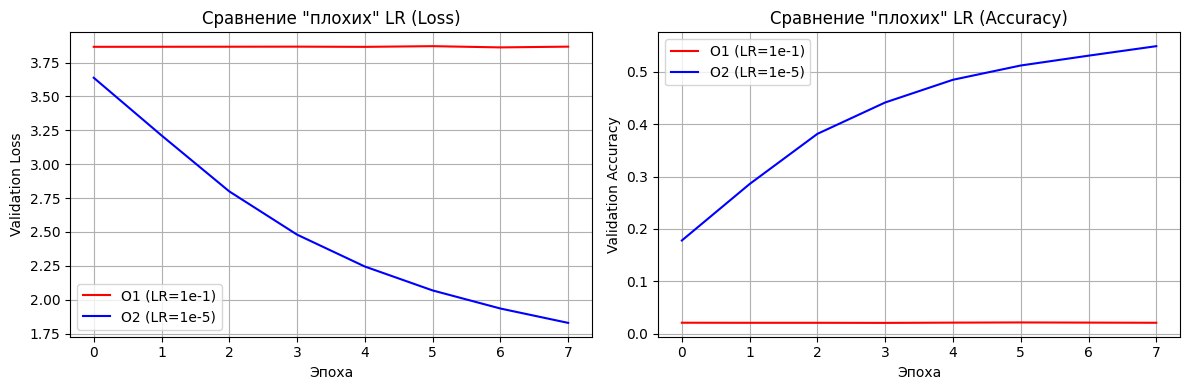

График для плохих LR сохранён в artifacts\figures\curves_lr_extremes.png


In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o1['val_loss'], label='O1 (LR=1e-1)', color='red')
plt.plot(history_o2['val_loss'], label='O2 (LR=1e-5)', color='blue')
plt.xlabel('Эпоха')
plt.ylabel('Validation Loss')
plt.title('Сравнение "плохих" LR (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1['val_acc'], label='O1 (LR=1e-1)', color='red')
plt.plot(history_o2['val_acc'], label='O2 (LR=1e-5)', color='blue')
plt.xlabel('Эпоха')
plt.ylabel('Validation Accuracy')
plt.title('Сравнение "плохих" LR (Accuracy)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'curves_lr_extremes.png')
plt.show()
print(f"График для плохих LR сохранён в {figures_dir / 'curves_lr_extremes.png'}")

## 6. Финальная оценка лучшей модели (E4) на тесте

In [23]:
model_e4.load_state_dict(torch.load(artifacts_dir / 'best_model.pt', map_location=device))
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Лучшая модель (E4) на test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Лучшая модель (E4) на test: loss=0.5330, acc=0.8243


## 7. Сохранение результатов в runs.csv

In [24]:
import csv

# Собираем данные для всех экспериментов
results_data = [
    {
        'experiment_id': 'E1',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_e1['val_loss']),
        'best_val_accuracy': max(history_e1['val_acc']),
        'best_val_loss': min(history_e1['val_loss'])
    },
    {
        'experiment_id': 'E2',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, Dropout(0.3)',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_e2['val_loss']),
        'best_val_accuracy': max(history_e2['val_acc']),
        'best_val_loss': min(history_e2['val_loss'])
    },
    {
        'experiment_id': 'E3',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, BatchNorm',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_e3['val_loss']),
        'best_val_accuracy': max(history_e3['val_acc']),
        'best_val_loss': min(history_e3['val_loss'])
    },
    {
        'experiment_id': 'E4',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, Dropout(0.3)',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_e4['val_loss']),
        'best_val_accuracy': best_val_acc_e4,
        'best_val_loss': min(history_e4['val_loss'])
    },
    {
        'experiment_id': 'O1',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, Dropout(0.3)',
        'optimizer': 'Adam',
        'lr': 1e-1,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_o1['val_loss']),
        'best_val_accuracy': max(history_o1['val_acc']),
        'best_val_loss': min(history_o1['val_loss'])
    },
    {
        'experiment_id': 'O2',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, Dropout(0.3)',
        'optimizer': 'Adam',
        'lr': 1e-5,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': len(history_o2['val_loss']),
        'best_val_accuracy': max(history_o2['val_acc']),
        'best_val_loss': min(history_o2['val_loss'])
    },
    {
        'experiment_id': 'O3',
        'dataset': 'EMNIST',
        'seed': SEED,
        'model_summary': '256-128, ReLU, Dropout(0.3)',
        'optimizer': 'SGD',
        'lr': 1e-2,
        'momentum': 0.9,
        'weight_decay': 1e-4,
        'epochs_trained': len(history_o3['val_loss']),
        'best_val_accuracy': max(history_o3['val_acc']),
        'best_val_loss': min(history_o3['val_loss'])
    },
]

csv_file = artifacts_dir / 'runs.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=results_data[0].keys())
    writer.writeheader()
    writer.writerows(results_data)

print(f"Результаты экспериментов сохранены в {csv_file}")


Результаты экспериментов сохранены в artifacts\runs.csv
